Demonstration of connecting to the AMPEL VRO alert stream published at Hopskotch.

### 1. Obtain current AMPEL alert set (in teststream)

In this notebook, we are using a cache system that points to an offset in the Kafka stream: When we sync our local data set, we start our stream where we left at the last sync.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")
warnings.filterwarnings("ignore", message="Wswiglal-redir-stdio")

from pathlib import Path
from ampel_report_tools import AmpelReportSet


from icecube_tools import IceCubeAlert, iter_icecube_public_alerts


In [2]:
CACHE_ROOT = Path("./cache_ampelaccess")

In [3]:
if (CACHE_ROOT / "objects").exists():
    ars = AmpelReportSet.load_cache(CACHE_ROOT)
    print(f"Loaded cache: {len(ars)} objects")
else:
    ars = AmpelReportSet()
    CACHE_ROOT.mkdir(parents=True, exist_ok=True)
    print("No cache yet, starting fresh")


Loaded cache: 0 objects


In [ ]:
host = 'kafka://kafka.scimma.org/'
topic = 'ampel.lsst.reports-test'
topic_url = f"{host}{topic}"
group_id = "<Hopskotch_credential_name>-<unique_suffix>"
# The group ID is used to identify the consumer group for Kafka.
# By using a unique group ID, Kafka will only deliver the messages that are new for this group. 
# Group ID has the fixed format "<Hopskotch_credential_name>-<unique_suffix>"
# You can find your Hopskotch credential name with this bash command: hop auth list
# To start a new group, just use a different unique suffix

In [5]:
stats = ars.update_from_stream(
    topic_url=topic_url,
    cache_root=CACHE_ROOT,
    group_id=group_id,
    start_at_if_new="EARLIEST",
    max_messages=None,
    persist=True,
)


print(stats)
ars.print_status()

{'n_messages': 2119, 'n_objects_added': 142, 'n_objects_updated': 1977, 'n_objects_total': 142}
AmpelReportSet status: 142 active / 142 total reports


### 2. Choose a classifier and model

In [6]:
# First, inspect the classifiers and models available in the data.
_ = ars.print_classifiers_summary(active_only=True, model_index=0, cls_threshold=0.01)

Classifier summary (active_reports):
  n_total:                 142
  with classification:     117
  with >=1 model:          117
  class-key threshold:     p >= 0.01
  inspected model_index:   0

Top classifier/model occurrences:

[0] ParsnipRiseDecline v1 / model=sn+2ulens+dwarfs
    reports: 117   with_probs: 117
    unique classes: 10
    P(CART), P(ILOT), P(PISN), P(SLSN-I), P(SNII), P(SNIa), P(SNIa91bg), P(SNIax), P(SNibc), P(TDE)


In [7]:
# Decide for yourself which classifiers and models to use for the radar plot and host info in the summary row.
classifier = 0
model = 0

### 3. Adding Filters

- `filter_class_prob(name, min_p, max_p)`  Select objects by class probability range.
- `filter_n_det(min_det, max_det, sigma_limit, band=None)`  Number of detections (SNR ≥ sigma), optional band.
- `filter_age(min_duration, max_duration, sigma_limit)`  Detection duration (days).
- `filter_time_since_first_det(min_days, max_days, sigma_limit, band=None)`  Time since first detection.
- `filter_time_since_last_det(min_days, max_days, sigma_limit, band=None)`  Time since last detection.
- `sigma_limit = 5.0` by default
- `filter_redshift(min_z, max_z)`  Host redshift.
- `filter_host_separation_arcsec(min_arcsec, max_arcsec)`  Transient–host angular separation (arcsec).
- `filter_sky_region(ra_range=(ra_min, ra_max), dec_range=(dec_min, dec_max))`  RA/Dec box (degrees).


- `clear_filters()`  Remove all active filters.
- `.active_filter_config` Read all active filters.


In [35]:
# Minimal SNIa probability
ars.filter_class_prob('P(SNIa)', min_prob=0.5, classifier=classifier, model=model)
ars.print_status()

AmpelReportSet status: 7 active / 142 total reports


In [36]:
# Minimal/maximal detections
ars.filter_n_det(min_det=10)
ars.print_status()

AmpelReportSet status: 7 active / 142 total reports


In [37]:
# Minimal transient duration
ars.filter_age(min_duration=7) # in days
ars.print_status()

AmpelReportSet status: 7 active / 142 total reports


In [38]:
# Time since first detection
ars.filter_time_since_first_det(max_days=100)
ars.print_status()

AmpelReportSet status: 7 active / 142 total reports


In [39]:
# Time since last detection
ars.filter_time_since_last_det(max_days=30)
ars.print_status()

AmpelReportSet status: 6 active / 142 total reports


In [40]:
# Minimal redshift
ars.filter_redshift(min_z=0.15)
ars.print_status()

AmpelReportSet status: 6 active / 142 total reports


In [41]:
# Maximal host separation
ars.filter_host_separation_arcsec(max_arcsec=10.0)
ars.print_status()

AmpelReportSet status: 6 active / 142 total reports


In [42]:
# Box sky region selection 
ars.filter_sky_region(ra_range=[-50,100], dec_range=[-50,30])
ars.print_status()

AmpelReportSet status: 6 active / 142 total reports


In [43]:
#ars.apply_filter_preset("recent_young_highz_snia")
#ars.print_status()

In [44]:
print(ars.active_filter_config)

Filters: P(SNIa) ∈ [0.5, 1] | n_det ∈ [10, 1000000000] (σ≥5) | det duration ∈ [7, inf] d (σ≥5) | Δt(first det) ∈ [0, 100] d (σ≥5) | Δt(last det) ∈ [0, 30] d (σ≥5) | host z ∈ [0.15, inf] | host sep ∈ [0, 10] arcsec | sky RA∈[-50,100] DEC∈[-50,30]


In [45]:
# Reset filters, if desired
#ars.clear_filters()
#ars.print_status()

### 4. Access a set of Ampel Reports 

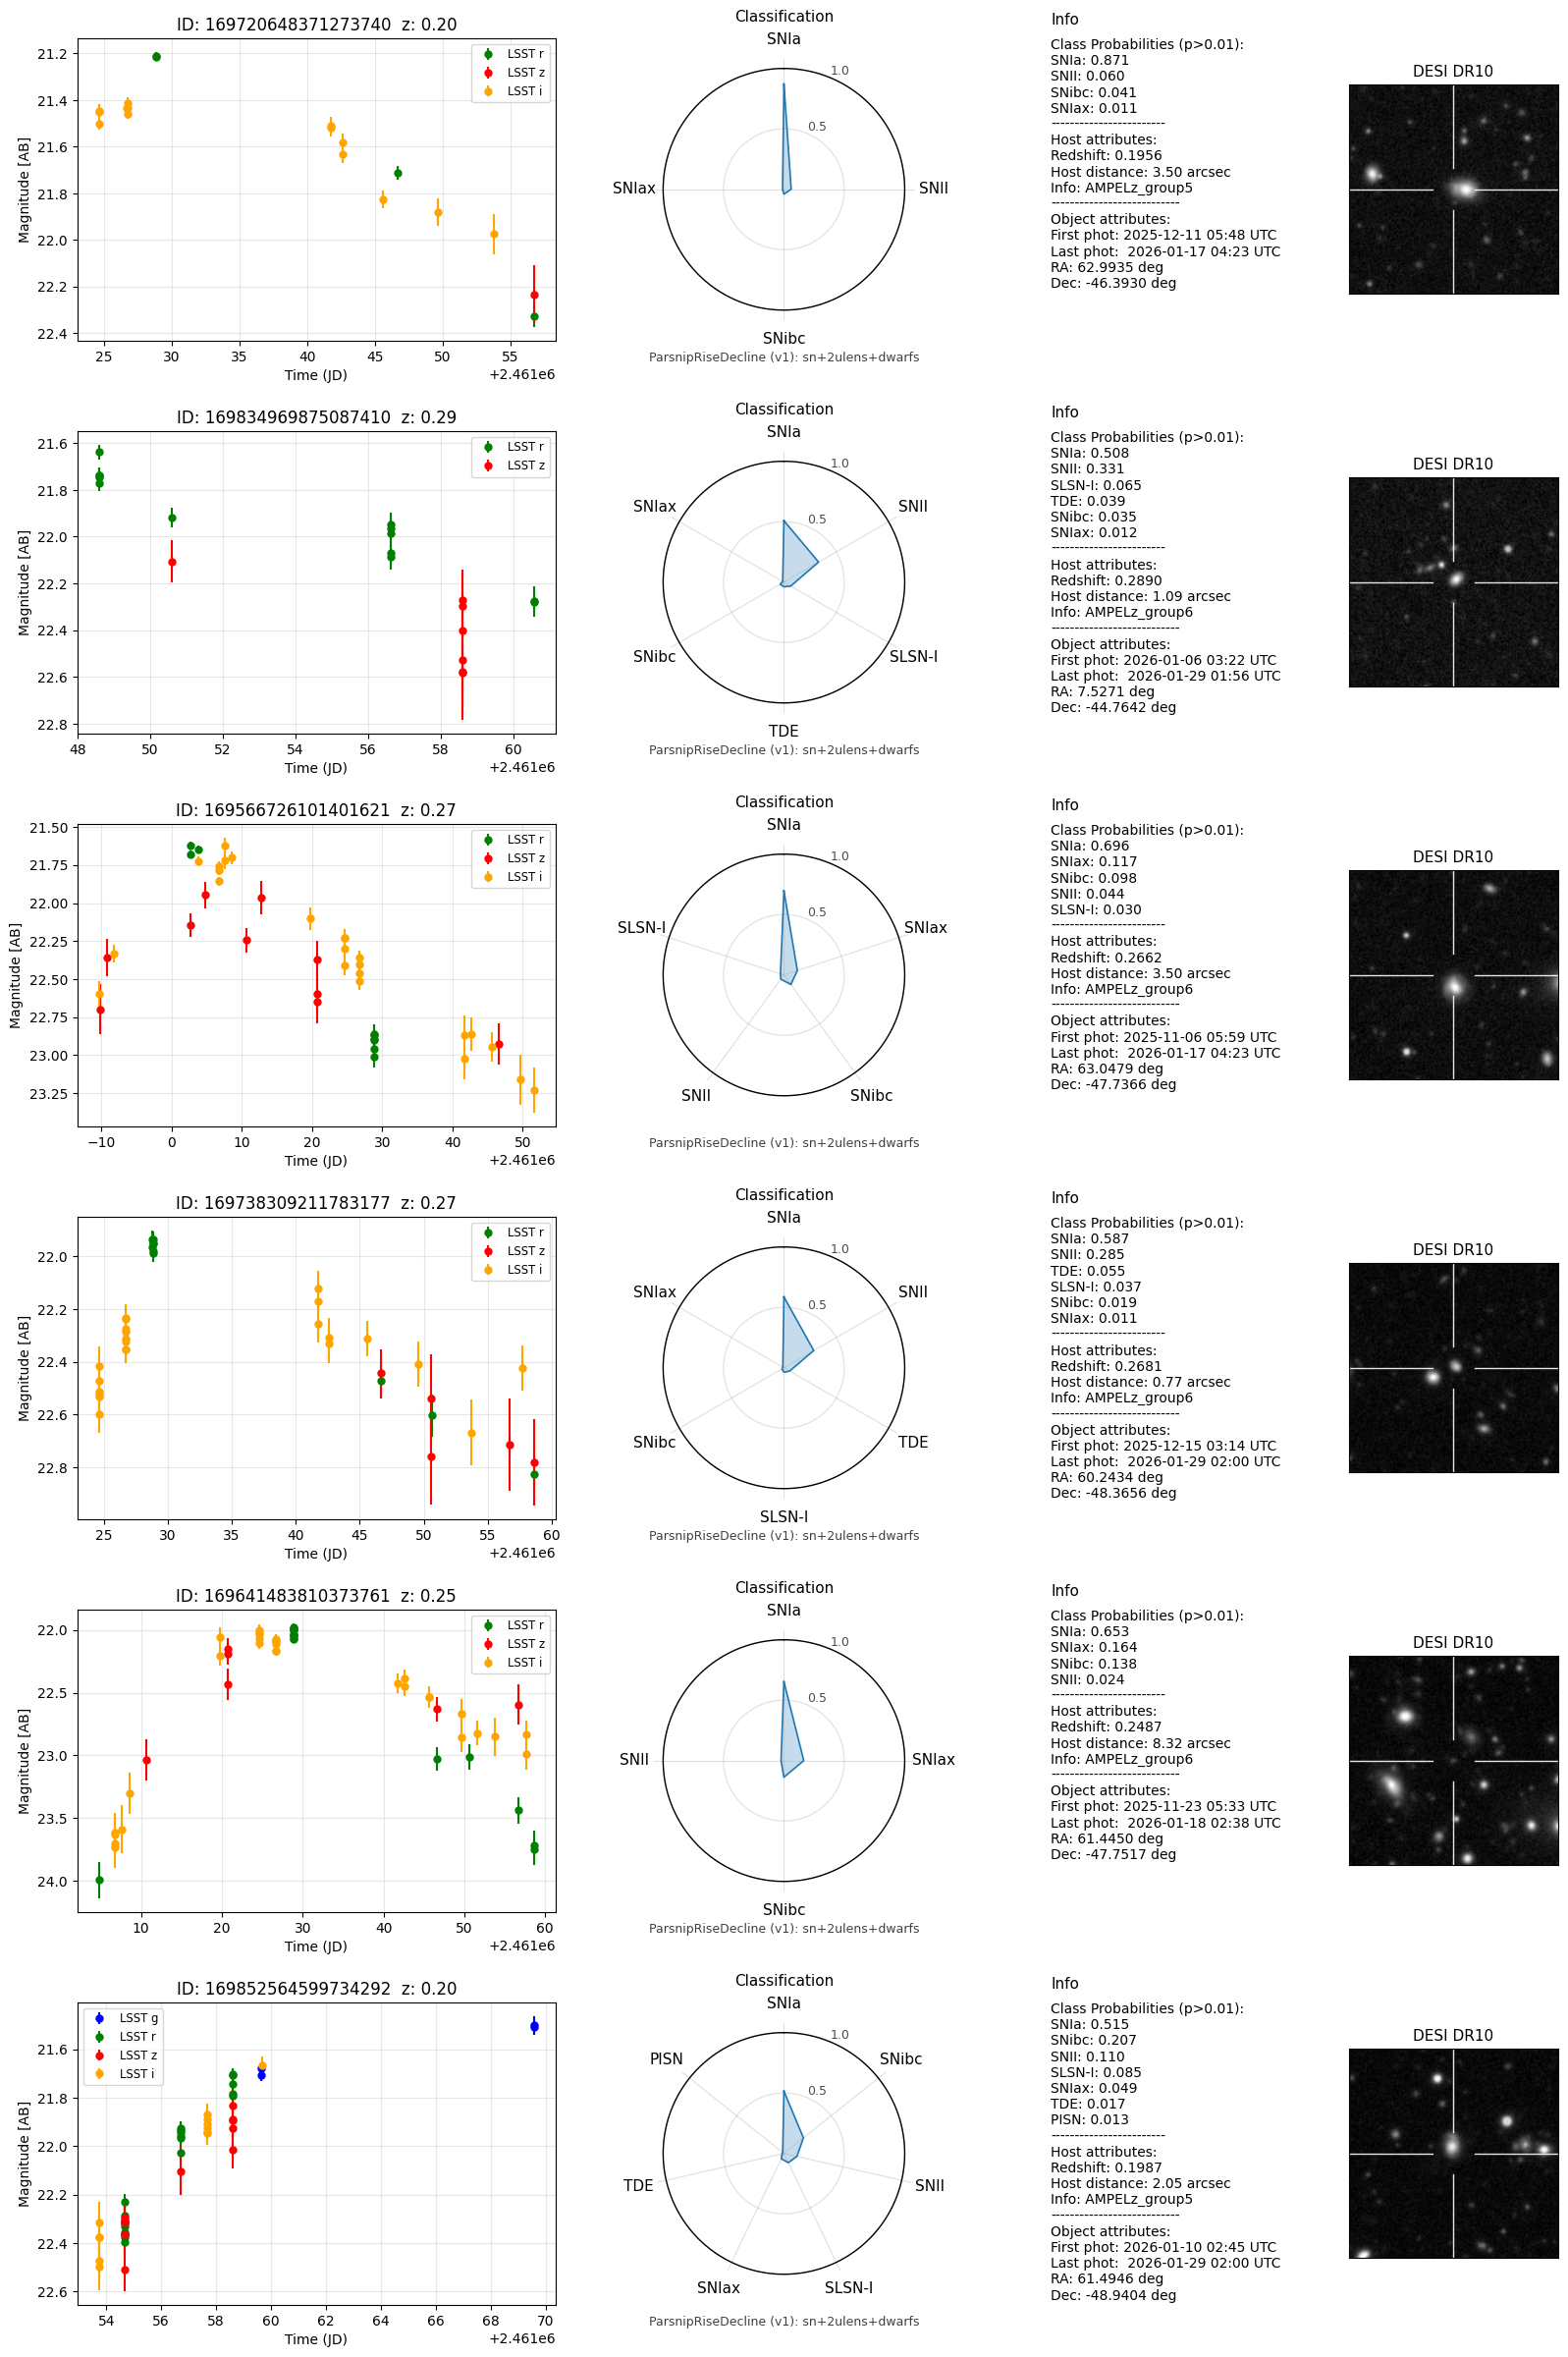

In [46]:
# Plot summary of all active transients in the set
_ = ars.plot_summary_rows(classifier=classifier, model=model)

In [20]:
#_ = ars.plot_lightcurves(grid=True)
#_ = ars.show_hosts(grid=False)
#_ = ars.show_classifications(grid=True)

### 5. Inspect the content of single Ampel Report.


In [21]:
report=ars.active_reports[0] # The first row of the summary table
#report=ars._reports["169641483810373761"] # Or directly by ID, if known

In [22]:
_ = report.inspect(snr_limit=5.0, cls_threshold=0.01) 


Top-level keys (6): classification, features, host, object, photometry, state
Object: id=169720648371273740  external_id=None
  RA/Dec: 62.99347, -46.39300 deg
Photometry: 21 pts  bands=['lssti', 'lsstr', 'lsstz']
  time: 2025-12-11 05:48 .. 2026-01-17 04:23 UTC
  detections (SNR≥5): 21  by band: {'lssti': 15, 'lsstr': 4, 'lsstz': 2}
Classification [0]: ParsnipRiseDecline (v1)  info='Trained on ELAsTiCC'
  Model (0): sn+2ulens+dwarfs
    SNIa          p=0.871
    SNII          p=0.060
    SNibc         p=0.041
    SNIax         p=0.011
Host:
  z = 0.1956
  distance = 3.50 arcsec
  info: 'AMPELz_group5'


In [23]:
report.phot_table[:5]

,time,flux,fluxerr,band,zp,zpsys
0,2.461021e+06,6145.415527,437.674011,lsstz,31.4,ab
1,2.461025e+06,9522.520508,247.380630,lssti,31.4,ab
2,2.461025e+06,9122.356445,223.105133,lssti,31.4,ab
3,2.461025e+06,9584.196289,271.110291,lssti,31.4,ab
4,2.461027e+06,9706.082031,210.657837,lssti,31.4,ab


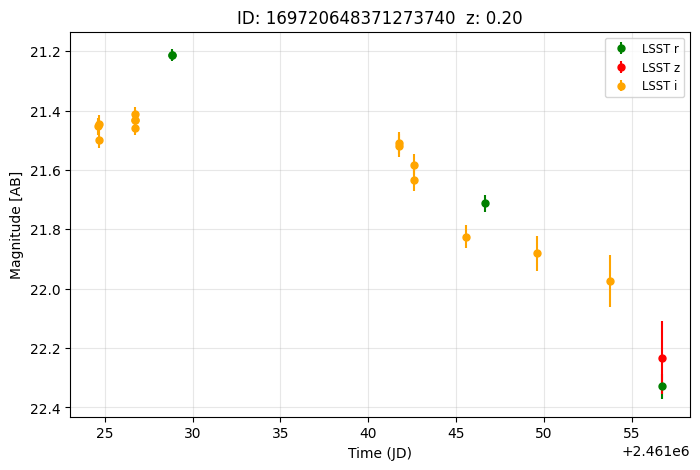

In [24]:
_ =report.plot_lightcurve()
#_ =report.show_classification()
#_ = report.show_hostinfo()
#_ = report.plot_summary_row()


### 6. Ingest Multi-Messenger-Alerts (using IceCube)

In [25]:
# First, we download a list of available public IceCube alerts and print their URL.
available_icecube_alerts = list(iter_icecube_public_alerts())
print(available_icecube_alerts)

[{'healpix_url': 'https://roc-2.icecube.wisc.edu/public/alerts/IceCube-260115A_skymap_probdensity_multiorder.fits.gz'}, {'healpix_url': 'https://roc-2.icecube.wisc.edu/public/alerts/IceCube-260125A_skymap_probdensity_multiorder.fits.gz'}]


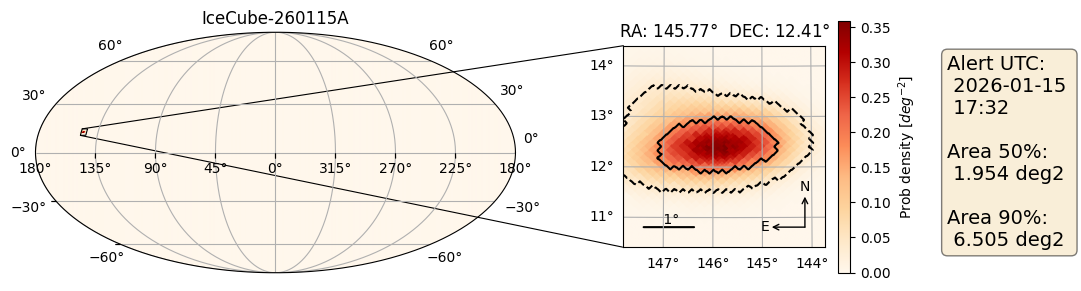

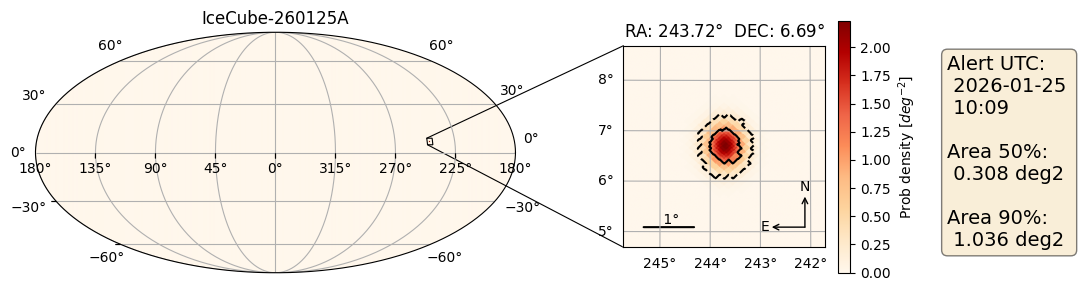

In [26]:
for a in available_icecube_alerts:
    IceCubeAlert.from_dict(a).plot(r=2, show_alert_datetime=True)

In [27]:
#We can also plot them individually
ic_alert= IceCubeAlert.from_dict(available_icecube_alerts[1])
#ic_alert.plot(r=2)
#ic_alert.plot(r=2, zoom=True)

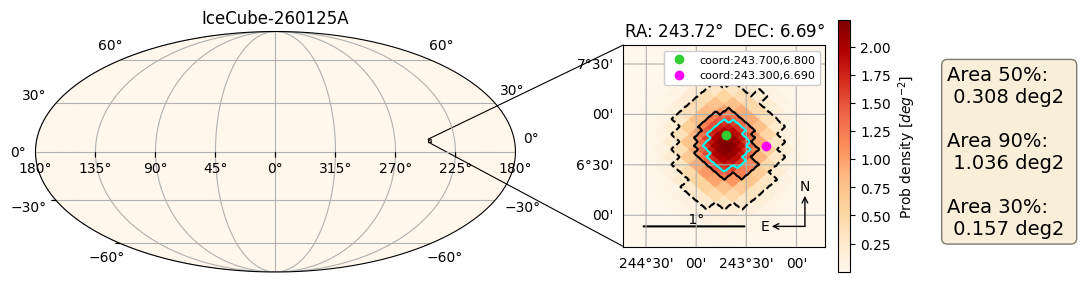

{'coord:243.700,6.800': True, 'coord:243.300,6.690': False}

In [28]:
# And we can check, if a source is contained in the alert
source_1 = (243.7,6.8 )
source_2 = (243.3,6.69)
ic_alert.contains_source(sources=[source_1, source_2], p_region=0.3, r=1)

### 7. Filter on basis of IceCube alerts

In [34]:
ars.clear_filters()
ars.print_status()

AmpelReportSet status: 142 active / 142 total reports


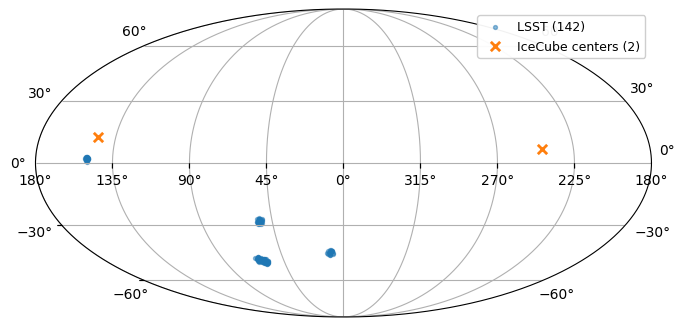

In [30]:
fig, ax = ars.plot_sky_mollweide(alpha_lsst=0.5, icecube_alerts=available_icecube_alerts, map_dir="./cache_ampelaccess/IceCubeAlerts")

In [31]:
# We can also match LSST sources to IceCube alerts to see, if there are important candidates.
# Not only by position, but also by time.
ic_to_objs, _ = ars.match_lsst_to_icecube_alerts(
    available_icecube_alerts,
    p_region=0.99,
    max_days_before=10, #relative to first detection
    max_days_after=30,
    verbose=False, 
    drop_empty=False)

for ic_id, objs in ic_to_objs.items():
    print(ic_id, objs)


IceCube-260115A_skymap_probdensity_multiorder.fits.gz []
IceCube-260125A_skymap_probdensity_multiorder.fits.gz []


In [32]:
# We can filter the LSST sources to be contained in an IceCube alert.
ars.filter_icecube_region(
    ic_alert, 
    p_region=0.99,
    max_days_before=10,
    max_days_after=30, 
    map_dir="./cache_ampelaccess/IceCubeAlerts")
ars.print_status()

AmpelReportSet status: 0 active / 142 total reports


In [33]:
#ic_alert.contains_source(sources=ars.active_reports, p_region=0.3, r=1)